# Check parquet integrity

The following notebook explores the metadata parquet created by build_metadata_table.py. Much of the following EDA relates to confirming joining logic and ensuring results are as expected. Finally, a cleaned dataframe is created. Also note that the following performs site/field-level embeddings, not well-level embeddings.

In [1]:
import pandas as pd
import numpy as np

# Load data
PATH = "../data/processed/master_metadata.parquet"
df = pd.read_parquet(PATH)
#df = df[df["plate"] != "BR00116992"] # TODO change

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

Shape: (129393, 44)

Columns:
 ['url_origdna', 'url_origlowzbf', 'url_orighighzbf', 'url_origbrightfield', 'url_origmito', 'url_origagp', 'url_origer', 'url_origrna', 'plate', 'well', 'site', 'metadata_abspositionz', 'metadata_abstime', 'metadata_binningx', 'metadata_binningy', 'metadata_channelid', 'metadata_channelname', 'metadata_col', 'metadata_exposuretime', 'metadata_fieldid', 'metadata_imageresolutionx', 'metadata_imageresolutiony', 'metadata_imagesizex', 'metadata_imagesizey', 'metadata_mainemissionwavelength', 'metadata_mainexcitationwavelength', 'metadata_maxintensity', 'metadata_objectivemagnification', 'metadata_objectivena', 'metadata_planeid', 'metadata_positionx', 'metadata_positiony', 'metadata_positionz', 'metadata_row', 'broad_sample', 'solvent', 'InChIKey', 'pert_iname', 'pubchem_cid', 'gene', 'pert_type', 'control_type', 'smiles', 'image_path']


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129393 entries, 0 to 129392
Data columns (total 44 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   url_origdna                        129393 non-null  object 
 1   url_origlowzbf                     129393 non-null  object 
 2   url_orighighzbf                    129393 non-null  object 
 3   url_origbrightfield                129393 non-null  object 
 4   url_origmito                       129393 non-null  object 
 5   url_origagp                        129393 non-null  object 
 6   url_origer                         129393 non-null  object 
 7   url_origrna                        129393 non-null  object 
 8   plate                              129393 non-null  object 
 9   well                               129393 non-null  object 
 10  site                               129393 non-null  int64  
 11  metadata_abspositionz              1293

In [3]:
df.head(20)

,url_origdna,url_origlowzbf,url_orighighzbf,url_origbrightfield,url_origmito,url_origagp,url_origer,url_origrna,plate,well,...,broad_sample,solvent,InChIKey,pert_iname,pubchem_cid,gene,pert_type,control_type,smiles,image_path
0,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,BR00116991,A01,...,BRD-A86665761-001-01-1,DMSO,TZDUHAJSIBHXDL-UHFFFAOYSA-N,gabapentin-enacarbil,9883933.0,CACNB4,trt,unknown,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,/scratch/creighton.jo/cellpainting/data/raw/im...
1,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,BR00116991,A01,...,BRD-A86665761-001-01-1,DMSO,TZDUHAJSIBHXDL-UHFFFAOYSA-N,gabapentin-enacarbil,9883933.0,CACNB4,trt,unknown,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,/scratch/creighton.jo/cellpainting/data/raw/im...
2,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,BR00116991,A01,...,BRD-A86665761-001-01-1,DMSO,TZDUHAJSIBHXDL-UHFFFAOYSA-N,gabapentin-enacarbil,9883933.0,CACNB4,trt,unknown,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,/scratch/creighton.jo/cellpainting/data/raw/im...
3,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,BR00116991,A01,...,BRD-A86665761-001-01-1,DMSO,TZDUHAJSIBHXDL-UHFFFAOYSA-N,gabapentin-enacarbil,9883933.0,CACNB4,trt,unknown,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,/scratch/creighton.jo/cellpainting/data/raw/im...
4,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,BR00116991,A01,...,BRD-A86665761-001-01-1,DMSO,TZDUHAJSIBHXDL-UHFFFAOYSA-N,gabapentin-enacarbil,9883933.0,CACNB4,trt,unknown,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,/scratch/creighton.jo/cellpainting/data/raw/im...
5,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,BR00116991,A01,...,BRD-A86665761-001-01-1,DMSO,TZDUHAJSIBHXDL-UHFFFAOYSA-N,gabapentin-enacarbil,9883933.0,CACNB4,trt,unknown,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,/scratch/creighton.jo/cellpainting/data/raw/im...
6,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpaint

In [4]:
# Check missing values
missing = df.isna().mean().sort_values(ascending=False)
print(missing.head(20))

pubchem_cid                          0.027822
url_origdna                          0.000000
metadata_positionz                   0.000000
metadata_mainemissionwavelength      0.000000
metadata_mainexcitationwavelength    0.000000
metadata_maxintensity                0.000000
metadata_objectivemagnification      0.000000
metadata_objectivena                 0.000000
metadata_planeid                     0.000000
metadata_positionx                   0.000000
metadata_positiony                   0.000000
metadata_row                         0.000000
url_origlowzbf                       0.000000
broad_sample                         0.000000
solvent                              0.000000
InChIKey                             0.000000
pert_iname                           0.000000
gene                                 0.000000
pert_type                            0.000000
control_type                         0.000000
dtype: float64


Note - image missingness due to only downloading subset of rows from plate

In [5]:
# Show treatment counts
if "broad_sample" in df.columns:
    print("\nunique compounds:", df["broad_sample"].nunique())


unique compounds: 307


In [6]:
# Check unique sites per well
if "site" in df.columns:
    print(df.groupby("well")["site"].nunique().describe())

count    384.0
mean       9.0
std        0.0
min        9.0
25%        9.0
50%        9.0
75%        9.0
max        9.0
Name: site, dtype: float64


In [7]:
# Confirm no missing plates/wells
assert df["plate"].notna().all(), "Missing plate values!"
assert df["well"].notna().all(), "Missing well values!"

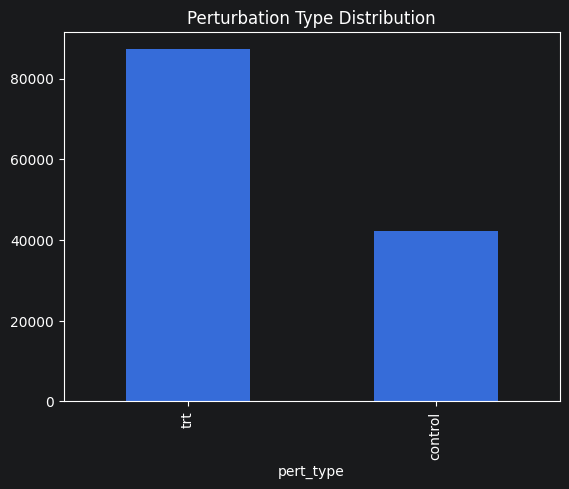

In [8]:
# Show perturbation type distribution
import matplotlib.pyplot as plt

df["pert_type"].value_counts().plot(kind="bar")
plt.title("Perturbation Type Distribution")
plt.show()

# EDA of parquet

In [9]:
# Descriptive stats
print("Unique plates:", df["plate"].nunique())
print("Unique wells:", df["well"].nunique())
print("Unique sites:", df["site"].nunique())
print("\nSites per well:")
print(df.groupby(["plate", "well"])["site"].nunique().describe())

Unique plates: 5
Unique wells: 384
Unique sites: 9

Sites per well:
count    1802.000000
mean        8.976138
std         0.368057
min         1.000000
25%         9.000000
50%         9.000000
75%         9.000000
max         9.000000
Name: site, dtype: float64


In [10]:
# Print gene counts
gene_counts = (
    df.groupby("gene")
    .size()
    .sort_values(ascending=False)
)

print(gene_counts.head(20))

print("\nUnique genes:", df["gene"].nunique())
print("Median rows per gene:", gene_counts.median())

gene
unknown    21752
HIF1A        720
MME          720
ELANE        720
EDNRB        720
DYRK1B       720
DNMT3A       720
DHH          720
MMP2         720
NTRK1        720
OPRL1        720
P3H1         720
PARP3        720
PDE7A        720
CSK          720
PLA2G1B      720
PLD1         720
EZH2         720
MET          720
FFAR4        720
dtype: int64

Unique genes: 161
Median rows per gene: 648.0


In [11]:
# Print controls
print(df["control_type"].value_counts(dropna=False))
print("\nTreatment vs controls:")
print(df["pert_type"].value_counts(dropna=False))

control_type
unknown           87193
negcon            21752
poscon_diverse     9648
poscon_cp          8712
poscon_orf         2088
Name: count, dtype: int64

Treatment vs controls:
pert_type
trt        87193
control    42200
Name: count, dtype: int64


In [12]:
# Confirm consistent image sizes
cols = ["metadata_imagesizex", "metadata_imagesizey"]
for c in cols:
    if c in df.columns:
        print(c)
        print(df[c].value_counts())

metadata_imagesizex
metadata_imagesizex
1080    129393
Name: count, dtype: int64
metadata_imagesizey
metadata_imagesizey
1080    129393
Name: count, dtype: int64


In [13]:
# Show duplicate biological-image rows
dup_mask = df.duplicated(["plate", "well", "site", "image_path"], keep=False)
print("Total duplicate rows:", dup_mask.sum())
if dup_mask.any():
    print("\nExample duplicates:")
    print(df[dup_mask].sort_values(["plate", "well", "site"]).head(20))

Total duplicate rows: 0


In [16]:
# Show sample image paths
sample = df.sample(5)
for _, row in sample.iterrows():
    print("\nWELL:", row["well"])
    print("SITE:", row["site"])
    print("IMAGE PATH:")
    print(row["image_path"])


WELL: O13
SITE: 4
IMAGE PATH:
/scratch/creighton.jo/cellpainting/data/raw/images/BR00116993/r15c13f04p01-ch2sk1fk1fl1.tiff

WELL: B01
SITE: 1
IMAGE PATH:
/scratch/creighton.jo/cellpainting/data/raw/images/BR00116992/r02c01f01p01-ch4sk1fk1fl1.tiff

WELL: G02
SITE: 9
IMAGE PATH:
/scratch/creighton.jo/cellpainting/data/raw/images/BR00116994/r07c02f09p01-ch1sk1fk1fl1.tiff

WELL: C18
SITE: 3
IMAGE PATH:
/scratch/creighton.jo/cellpainting/data/raw/images/BR00116991/r03c18f03p01-ch8sk1fk1fl1.tiff

WELL: L16
SITE: 1
IMAGE PATH:
/scratch/creighton.jo/cellpainting/data/raw/images/BR00116991/r12c16f01p01-ch1sk1fk1fl1.tiff


# Preprocessing

In [18]:
keep_cols = [
    "image_path",
    "plate",
    "well",
    "site",
    "broad_sample",
    "pert_iname",
    "pert_type",
    "control_type",
    "gene",
    "smiles",
    "InChIKey",
]
clean_df = df[keep_cols].copy()
clean_df.head(20)

,image_path,plate,well,site,broad_sample,pert_iname,pert_type,control_type,gene,smiles,InChIKey
0,/scratch/creighton.jo/cellpainting/data/raw/im...,BR00116991,A01,1,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,unknown,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N
1,/scratch/creighton.jo/cellpainting/data/raw/im...,BR00116991,A01,1,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,unknown,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N
2,/scratch/creighton.jo/cellpainting/data/raw/im...,BR00116991,A01,1,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,unknown,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N
3,/scratch/creighton.jo/cellpainting/data/raw/im...,BR00116991,A01,1,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,unknown,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N
4,/scratch/creighton.jo/cellpainting/data/raw/im...,BR00116991,A01,1,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,unknown,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N
5,/scratch/creighton.jo/cellpainting/data/raw/im...,BR00116991,A01,1,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,unknown,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N
6,/scratch/creighton.jo/cellpainting/data/raw/im...,BR00116991,A01,1,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,unknown,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N
7,/scratch/creighton.jo/cellpainting/data/raw/im...,BR00116991,A01,1,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,unknown,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N
8,/scratch/creighton.jo/cellpainting/data/raw/im...,BR00116991,A01,2,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,unknown,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N
9,/scratch/creighton.jo/cellpainting/data/raw/im...,BR00116991,A01,2,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,unknown,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N


In [19]:
print(clean_df["plate"].value_counts())

plate
BR00116991    27648
BR00116995    27648
BR00116994    27576
BR00116993    27352
BR00116992    19169
Name: count, dtype: int64


In [20]:
compound_counts = df["broad_sample"].value_counts()

print("Top 1% compounds fraction:",
      compound_counts.head(int(len(compound_counts)*0.01)).sum() /
      compound_counts.sum())

Top 1% compounds fraction: 0.17923689844118307


In [21]:
# Plate balance
print("\nPlate distribution:")
print(df["plate"].value_counts(normalize=True))

# Compound skew
compound_counts = df["broad_sample"].value_counts()

print("\nTop 10 compounds:")
print(compound_counts.head(10))

print("\nTop 1% dominance ratio:")
top_1pct = compound_counts.head(int(len(compound_counts) * 0.01)).sum()
print(top_1pct / compound_counts.sum())


Plate distribution:
plate
BR00116991    0.213675
BR00116995    0.213675
BR00116994    0.213118
BR00116993    0.211387
BR00116992    0.148146
Name: proportion, dtype: float64

Top 10 compounds:
broad_sample
unknown                   21752
BRD-K03406345-001-21-1      720
BRD-K64800655-001-09-0      720
BRD-K41599323-001-02-3      720
BRD-K23363278-001-02-1      720
BRD-K86525559-001-07-8      720
BRD-K25412176-001-01-9      720
BRD-K64890080-001-02-1      720
BRD-K33882852-003-02-8      720
BRD-K42191735-001-08-7      648
Name: count, dtype: int64

Top 1% dominance ratio:
0.17923689844118307
